<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `NetworkTutorial.mlx`
- Fidelity status: `exact`
- Remaining justified differences: Mirrors the MATLAB helpfile section order and all 13 published figures with a native Python network simulator and MATLAB-style `Analysis` workflow. Only inherent NumPy vs Simulink random streams differ.


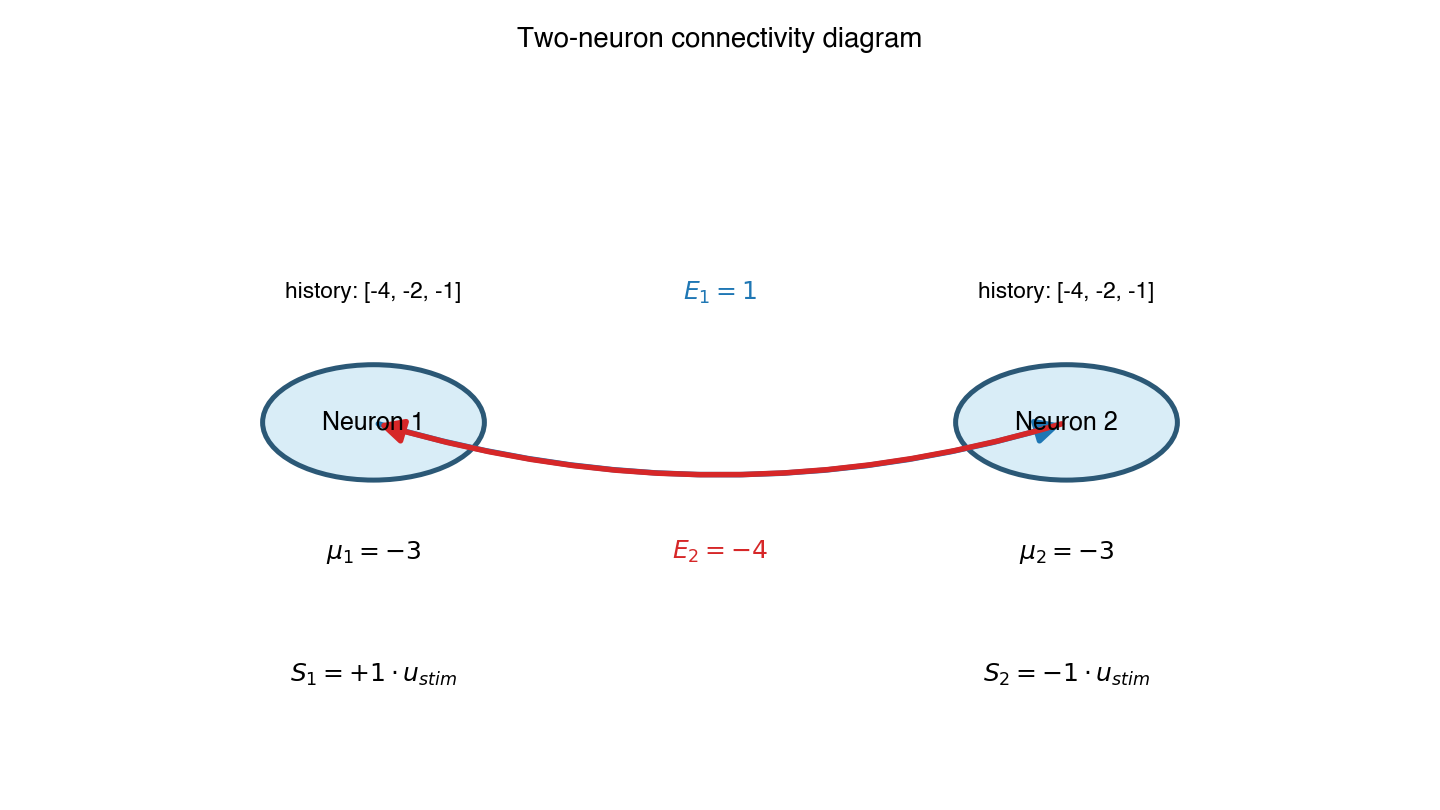

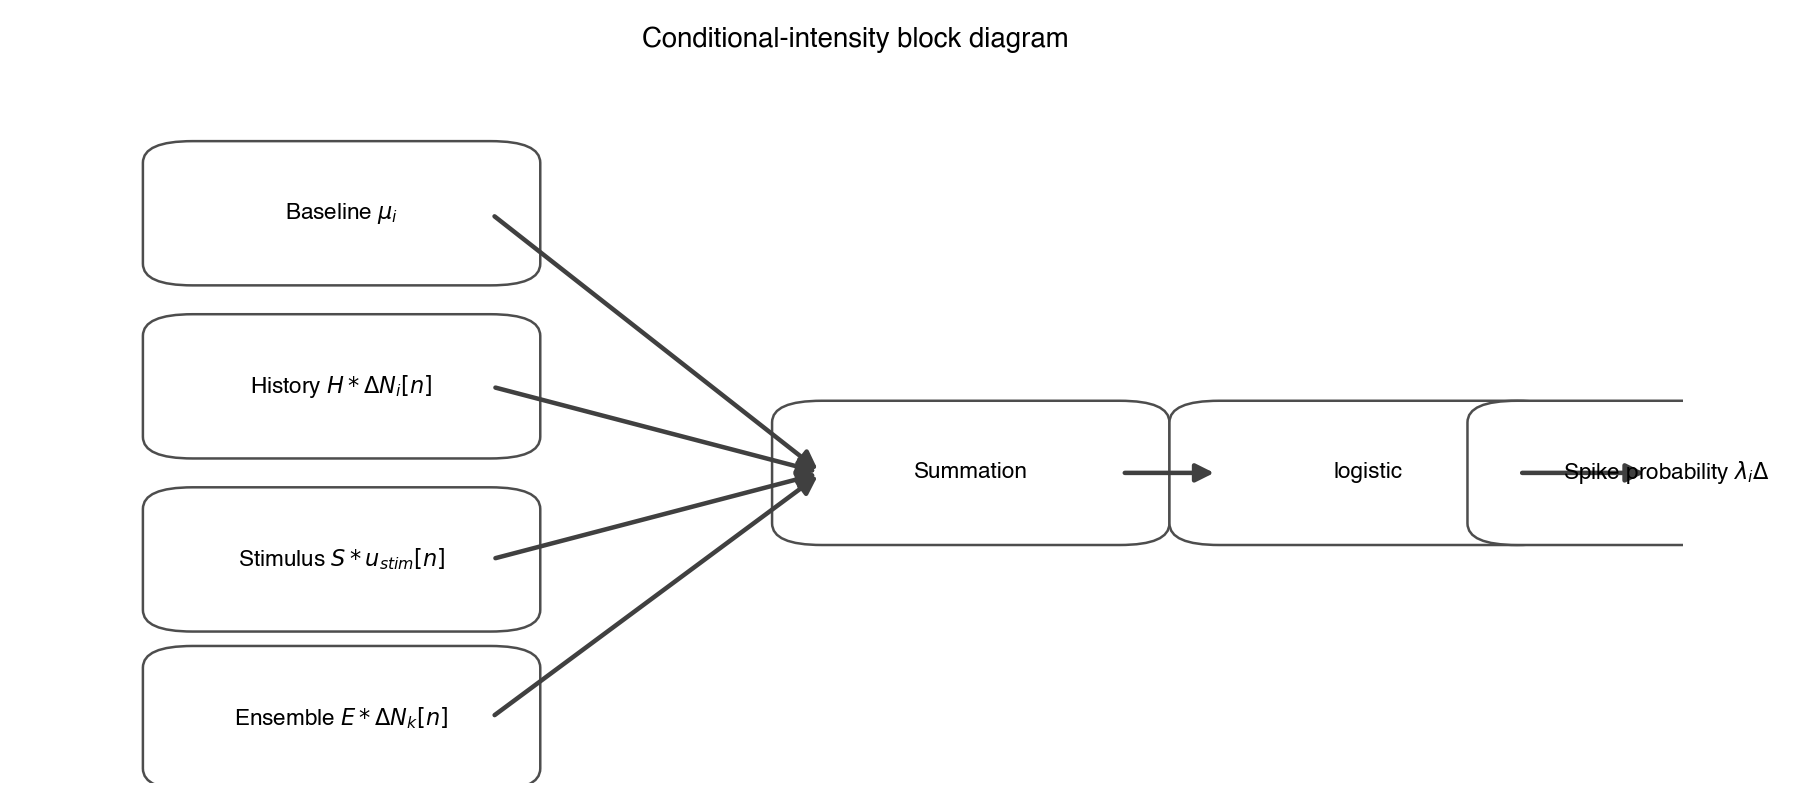

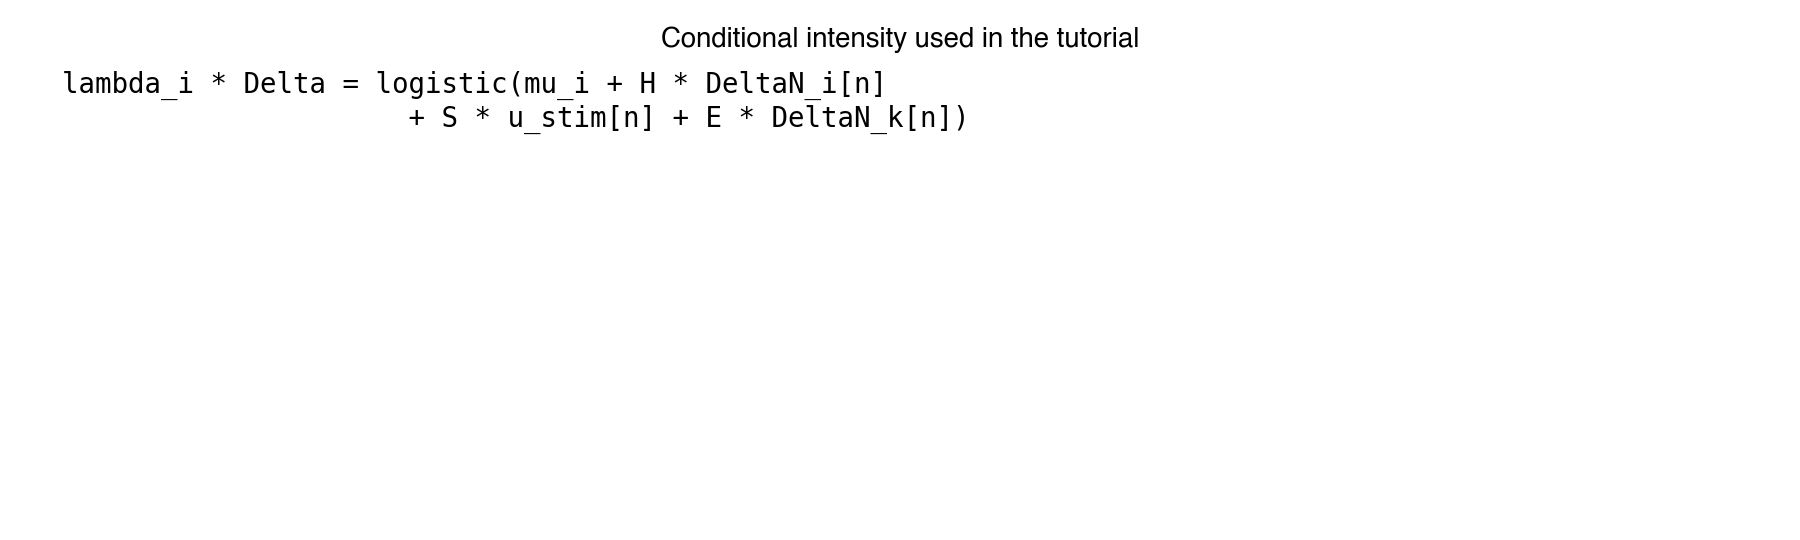

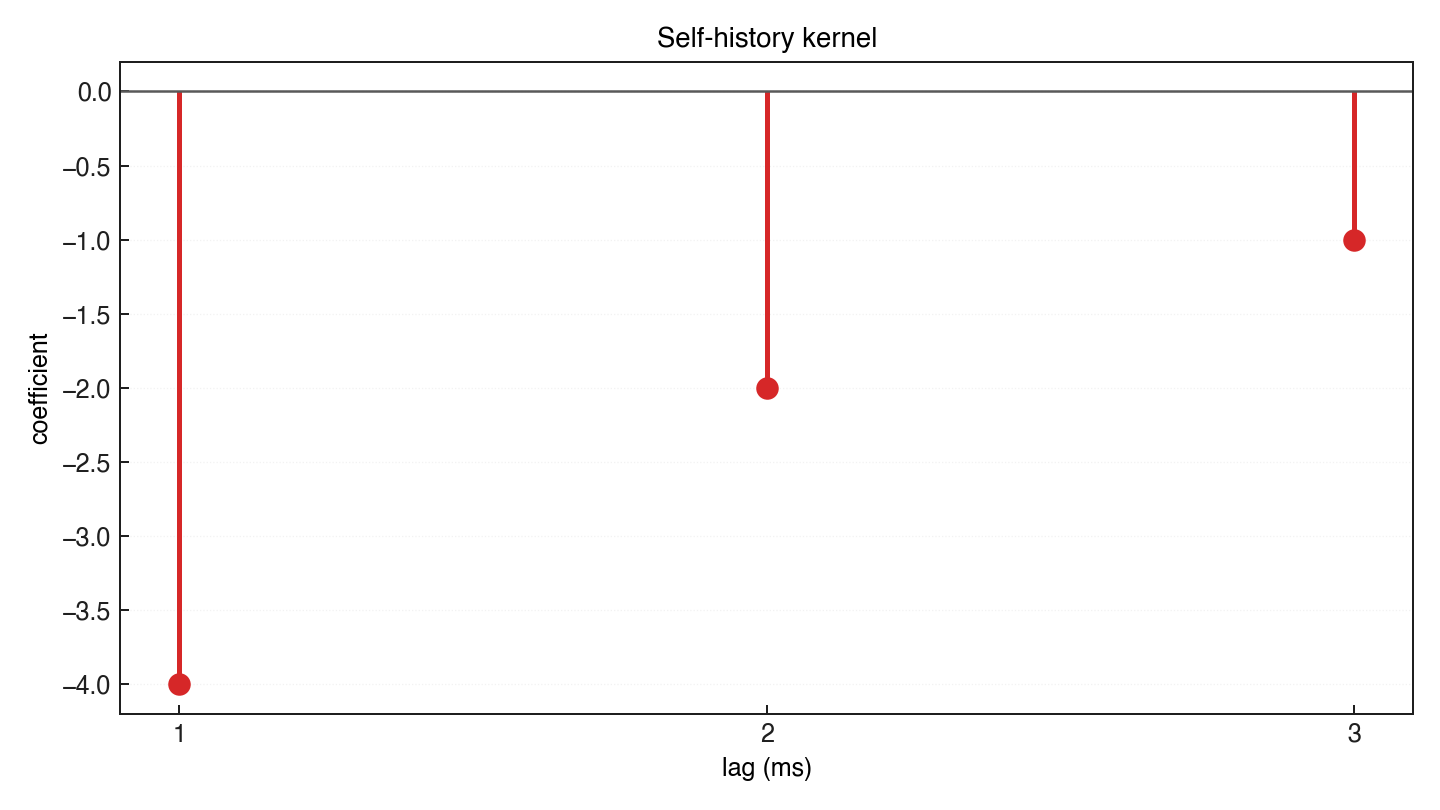

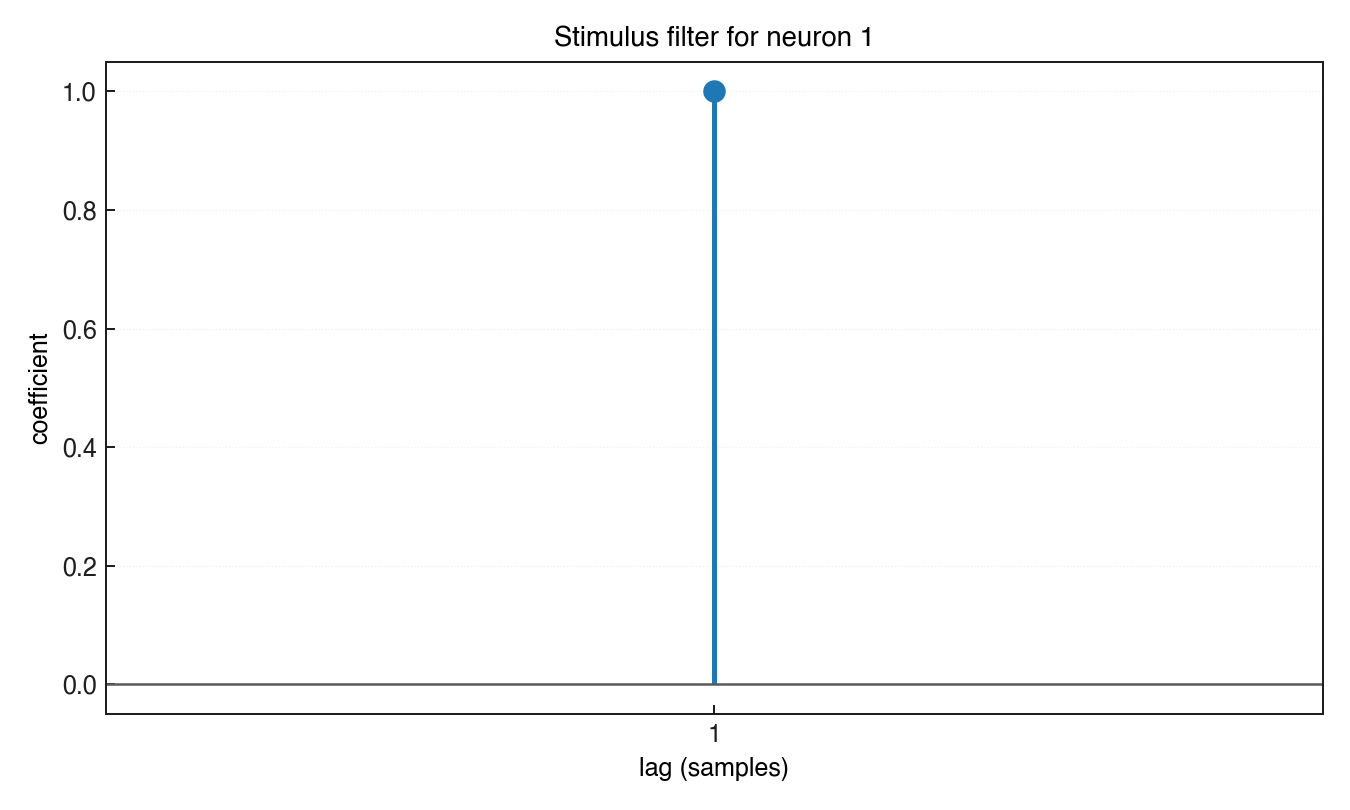

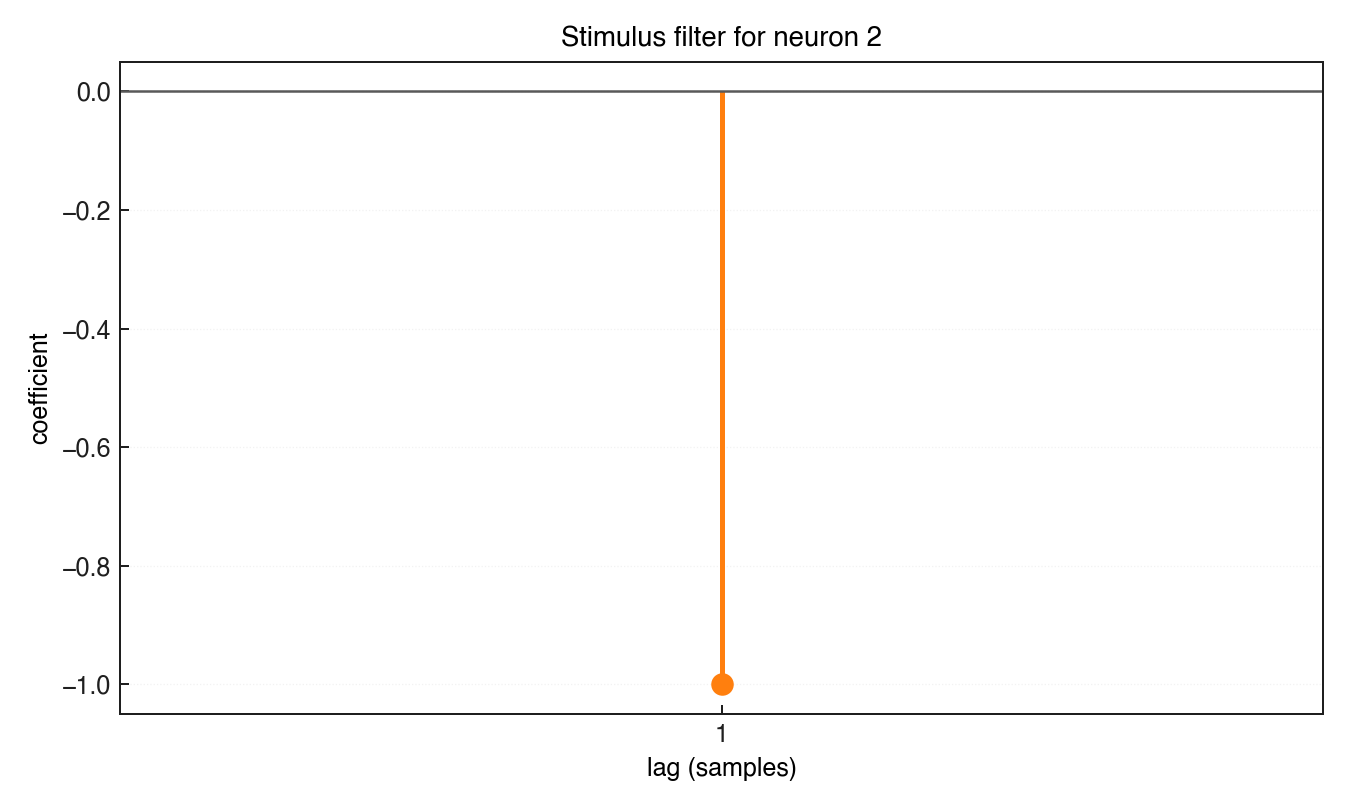

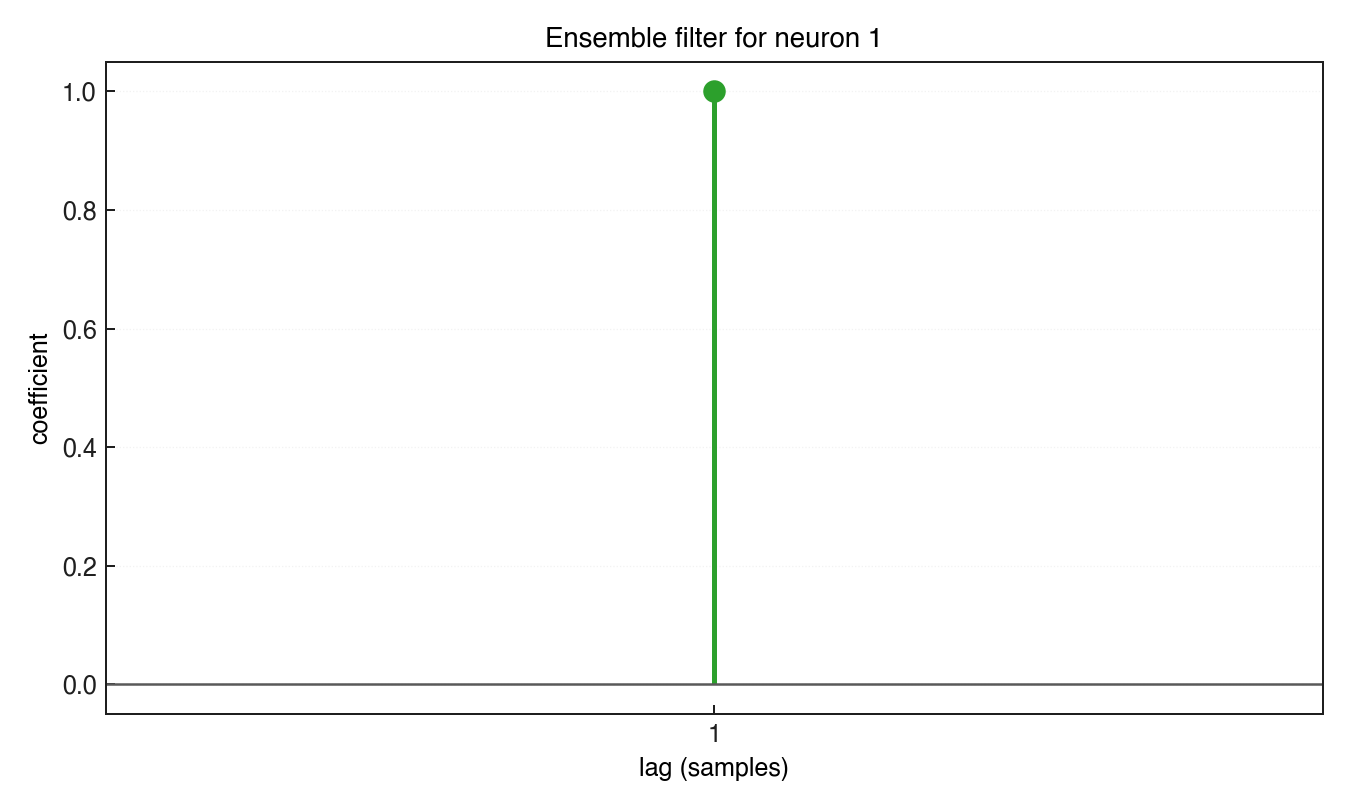

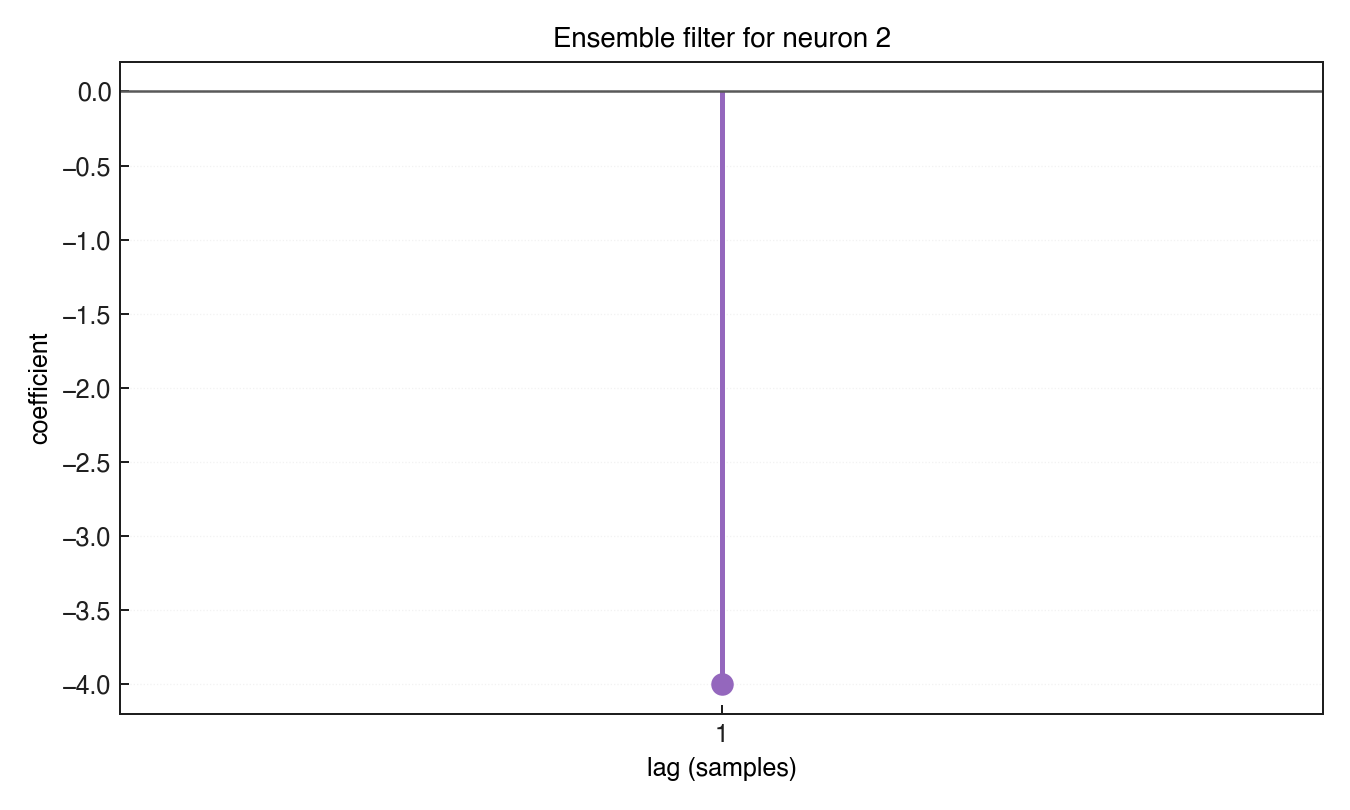

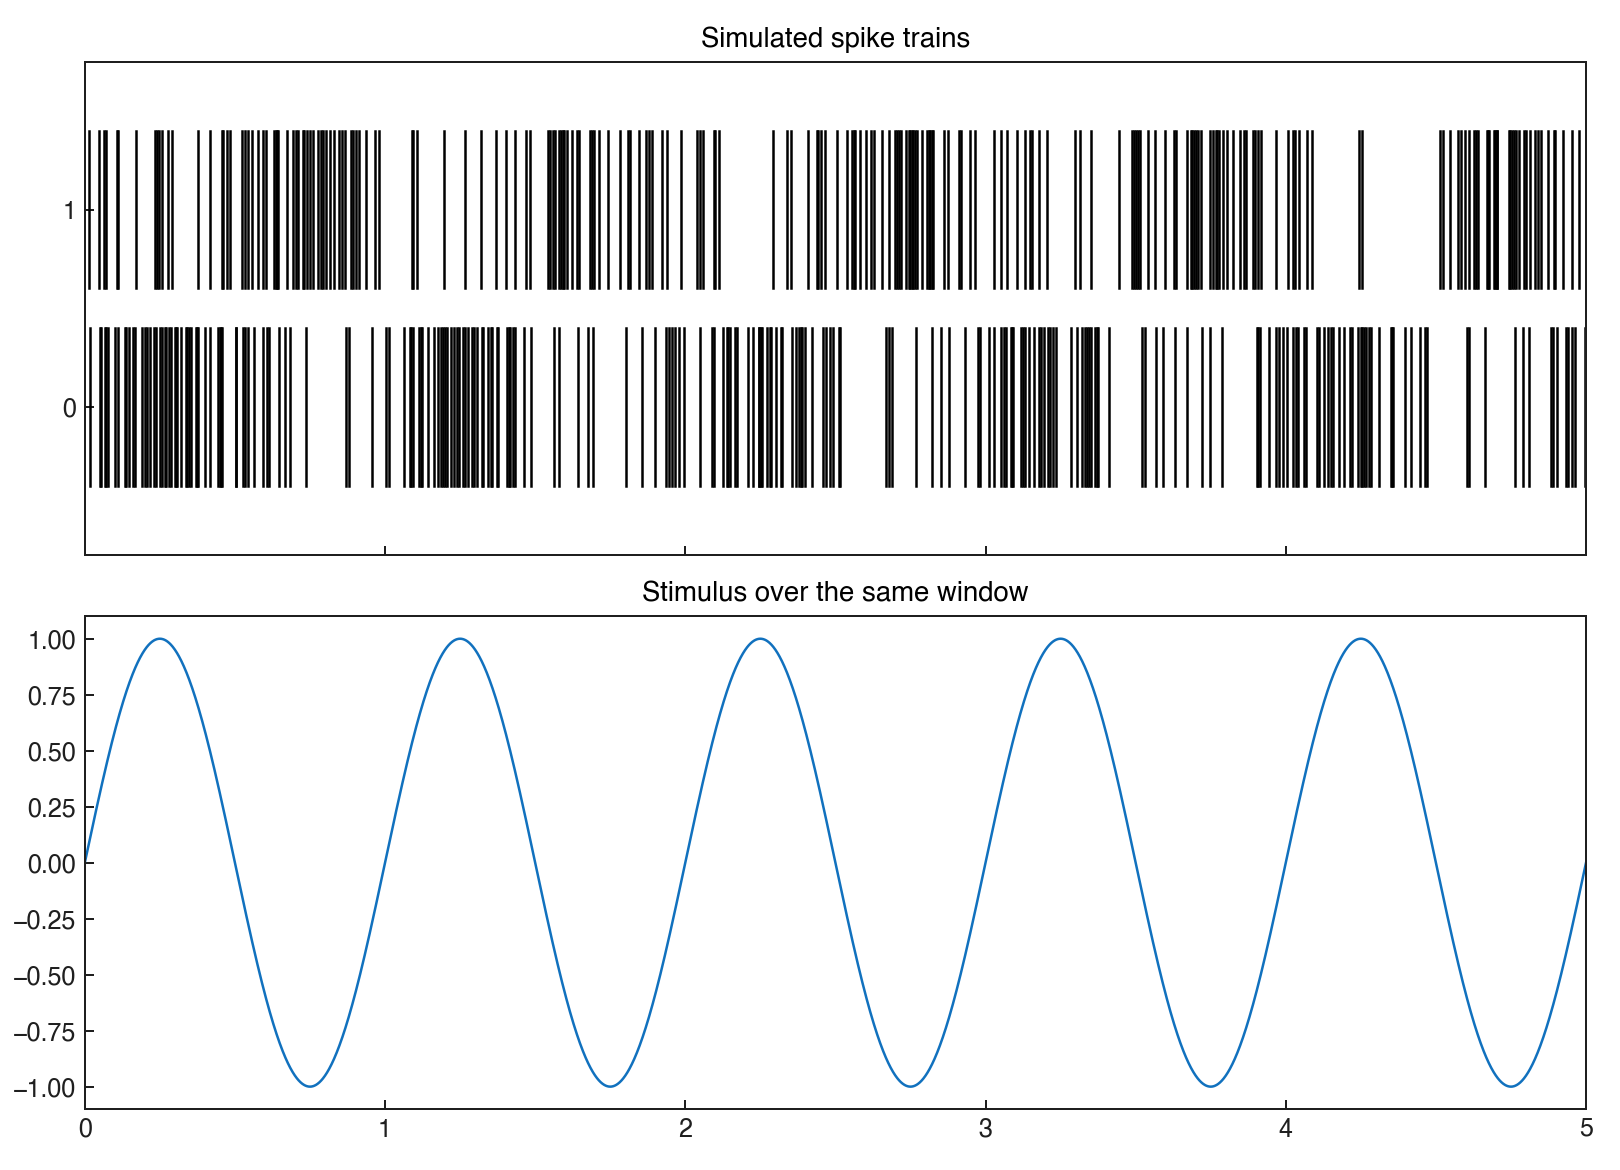

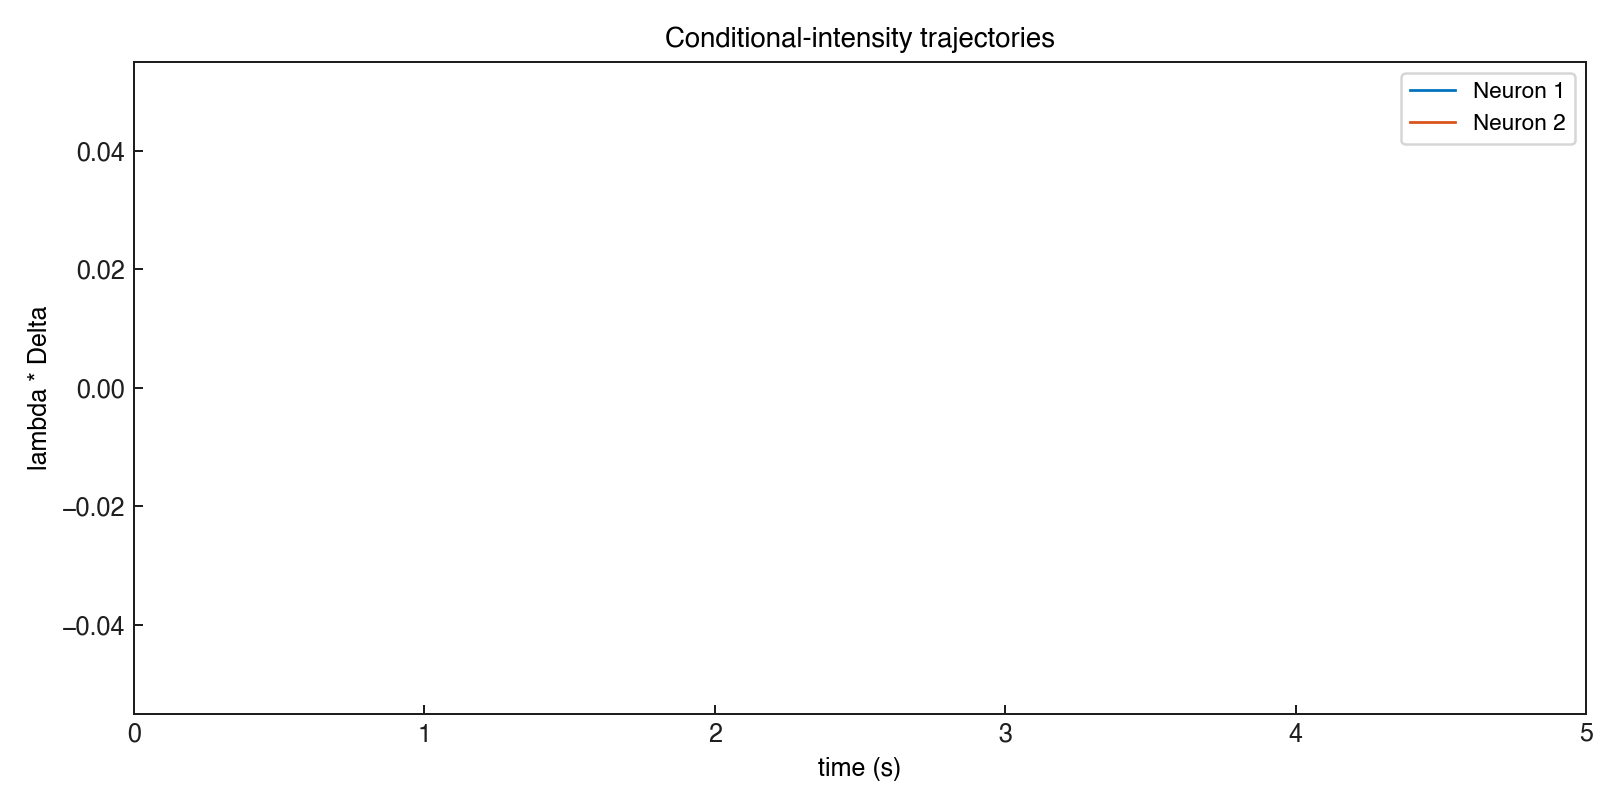

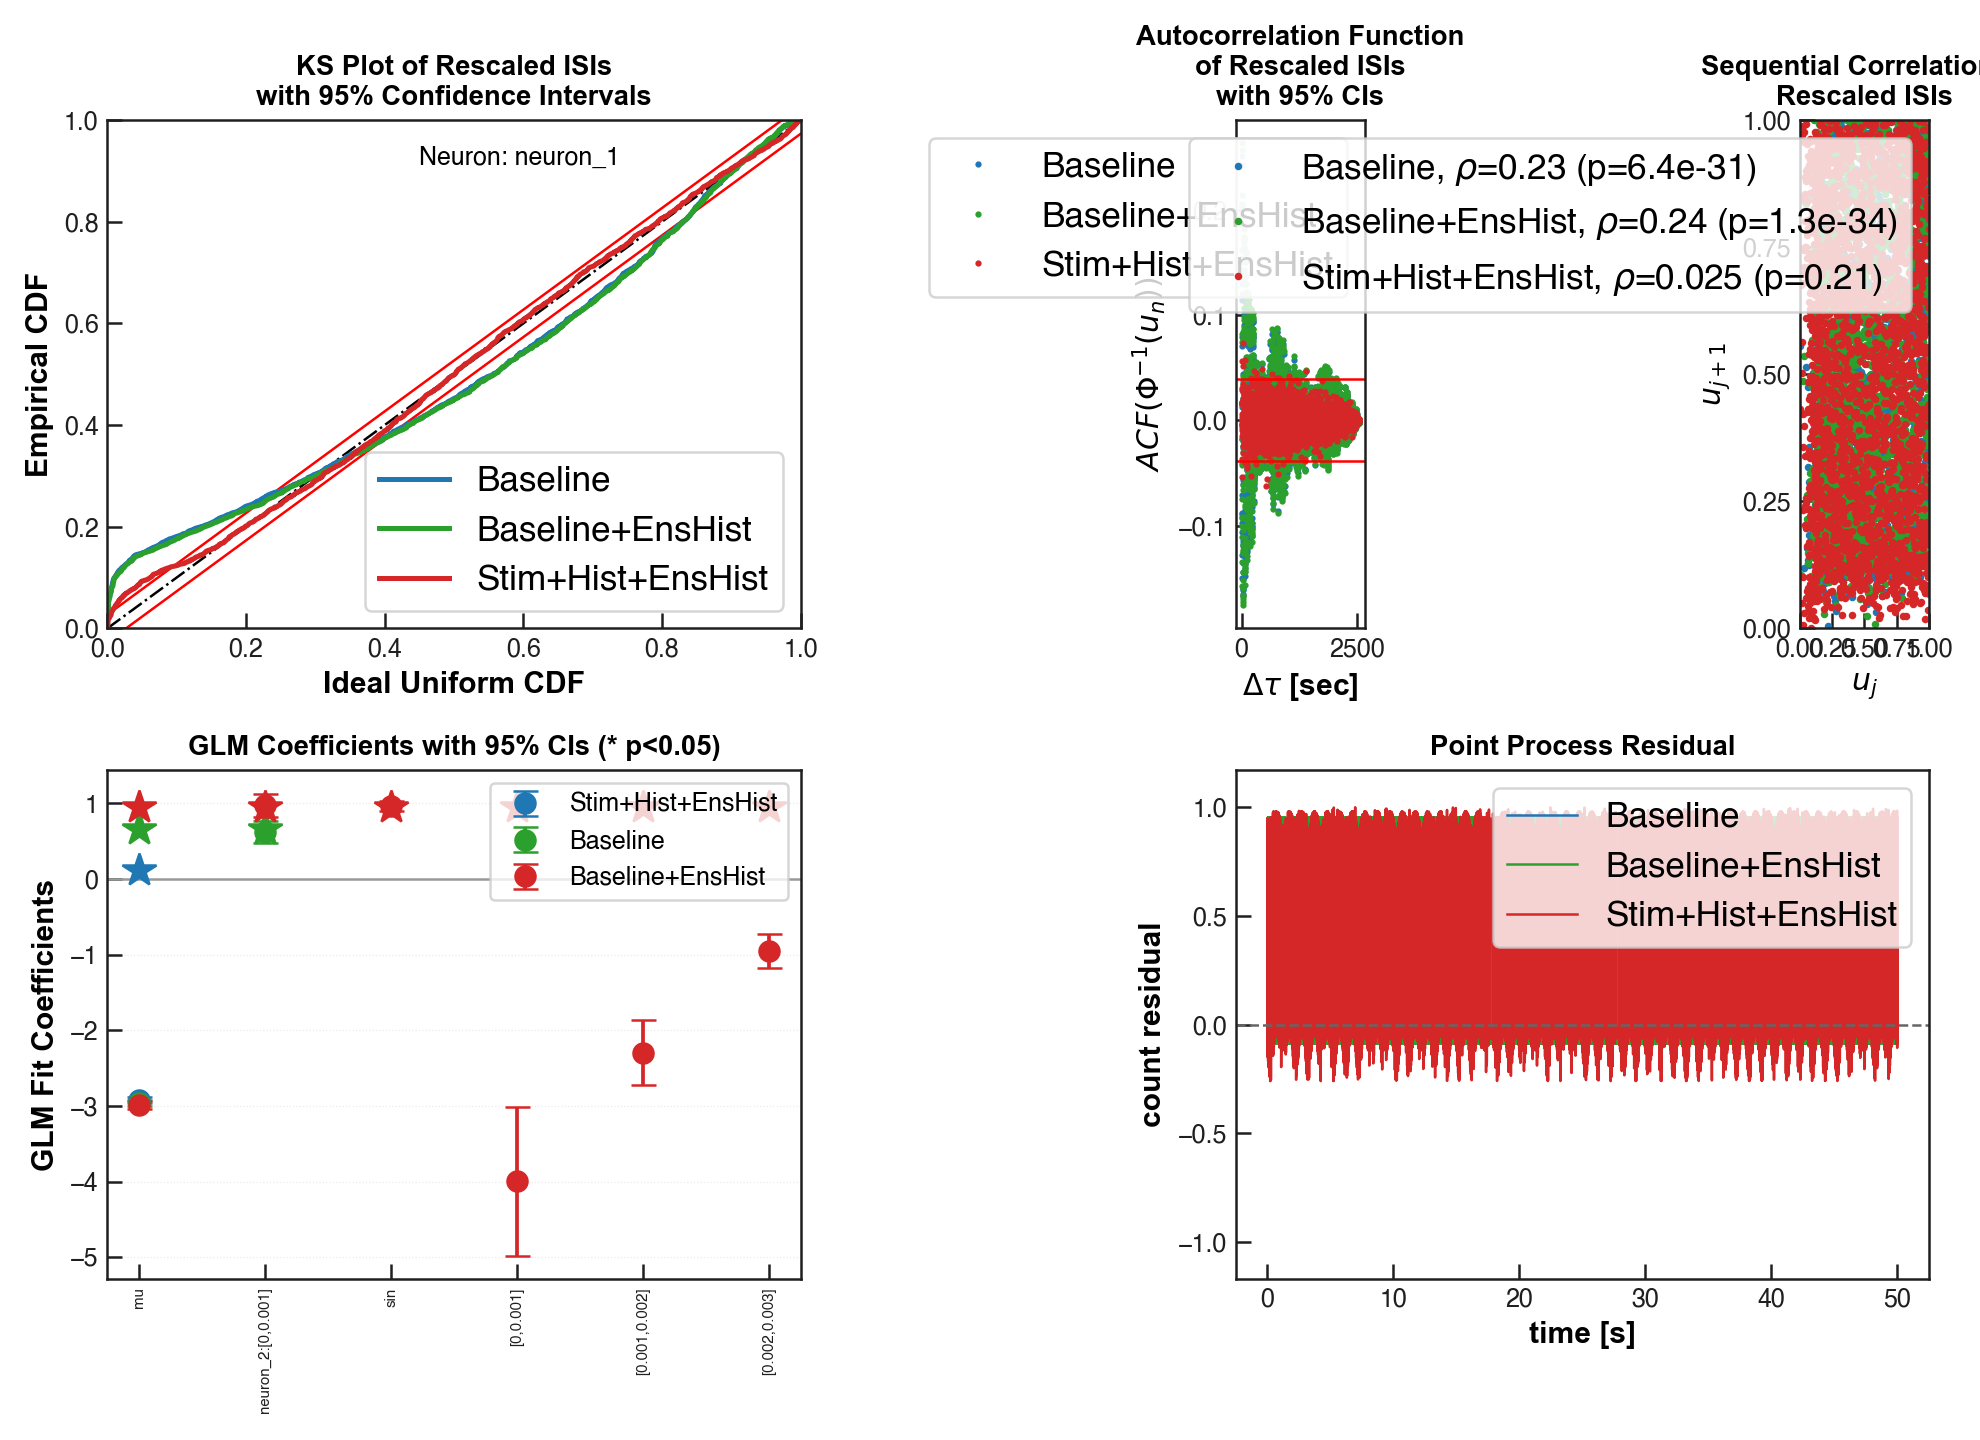

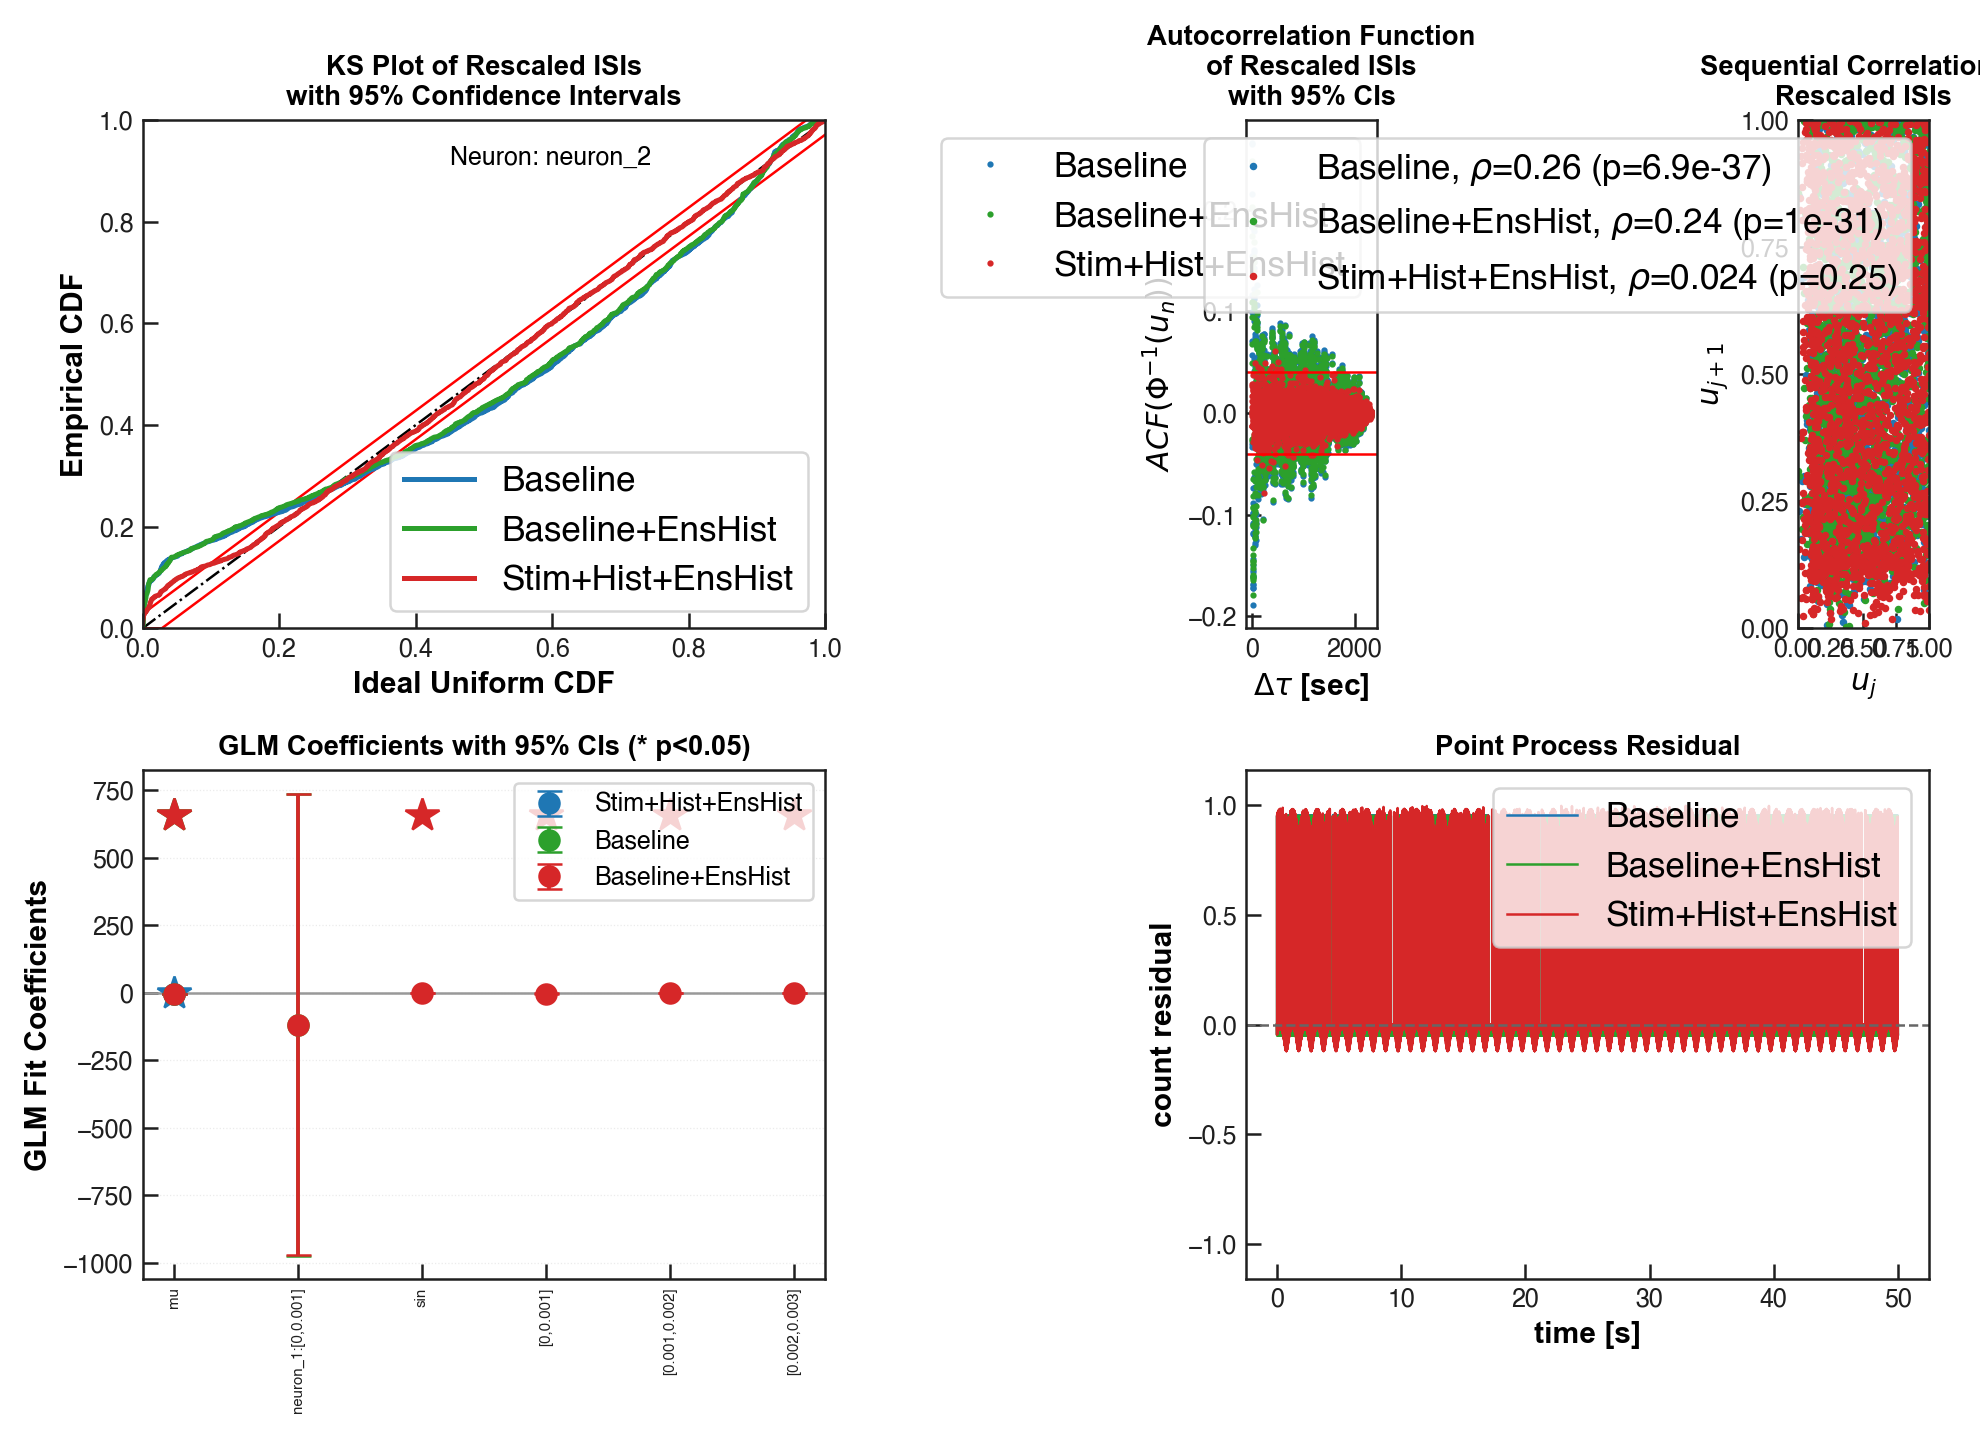

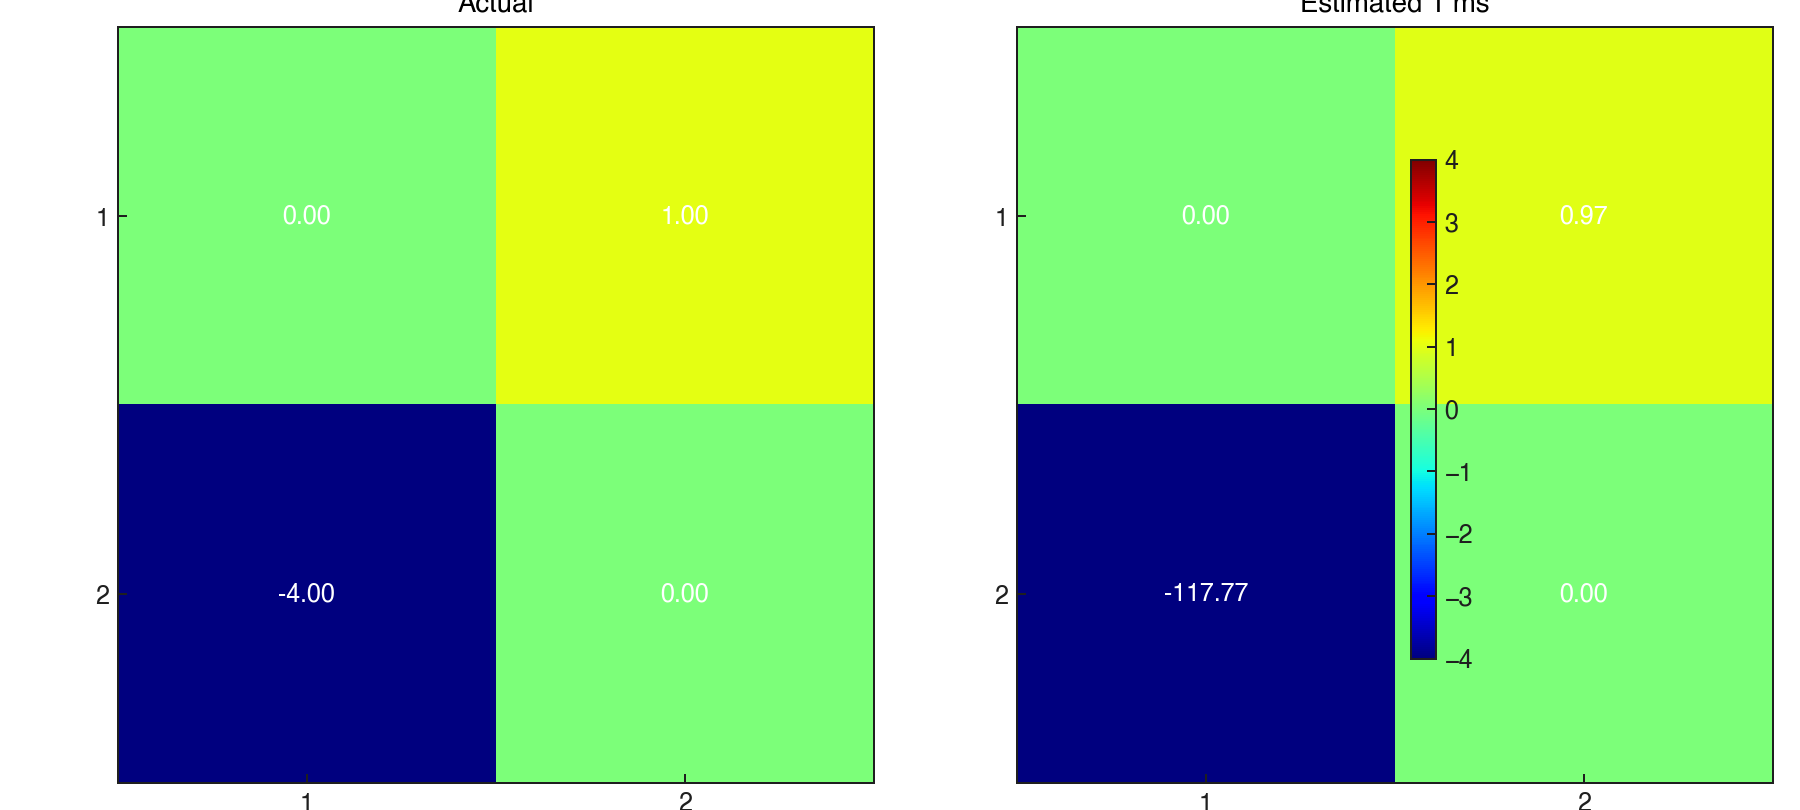

In [ ]:
# nSTAT-python notebook example: NetworkTutorial
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch

from nstat import Analysis, Covariate, History, Trial, TrialConfig
from nstat.ConfigColl import ConfigColl
from nstat.CovColl import CovColl
from nstat.notebook_figures import FigureTracker
from nstat.simulators import simulate_two_neuron_network

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='NetworkTutorial', output_root=OUTPUT_ROOT, expected_count=13)


def _figure(label: str, *, figsize=(8.5, 4.5)):
    fig = __tracker.new_figure(label)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _text_panel(fig, title: str, lines):
    ax = fig.subplots(1, 1)
    ax.axis("off")
    ax.set_title(title)
    ax.text(
        0.02,
        0.98,
        "\n".join(lines),
        va="top",
        ha="left",
        family="monospace",
        fontsize=11,
        transform=ax.transAxes,
    )
    return ax


def _stem_kernel(ax, coeffs, title: str, xlabel: str, color: str):
    coeffs = np.asarray(coeffs, dtype=float).reshape(-1)
    x = np.arange(1, coeffs.size + 1, dtype=float)
    markerline, stemlines, baseline = ax.stem(x, coeffs, basefmt=" ")
    plt.setp(markerline, color=color, markersize=8)
    plt.setp(stemlines, color=color, linewidth=2.0)
    baseline.set_visible(False)
    ax.axhline(0.0, color="0.35", linewidth=1.0)
    ax.set_xticks(x)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("coefficient")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)


def _draw_network(ax, actual_network):
    ax.set_title("Two-neuron connectivity diagram")
    ax.axis("off")
    positions = {1: (0.25, 0.5), 2: (0.75, 0.5)}
    for idx, (x, y) in positions.items():
        ax.add_patch(Circle((x, y), 0.08, facecolor="#d9edf7", edgecolor="#2b5876", linewidth=2.0))
        ax.text(x, y, f"Neuron {idx}", ha="center", va="center", fontsize=10, weight="bold")
        ax.text(x, y - 0.18, f"$\\mu_{idx}={-3}$", ha="center", va="center", fontsize=10)
        ax.text(x, y + 0.18, "history: [-4, -2, -1]", ha="center", va="center", fontsize=9)

    arrow12 = FancyArrowPatch(
        positions[1],
        positions[2],
        arrowstyle="-|>",
        mutation_scale=20,
        linewidth=2.2,
        color="#1f77b4",
        connectionstyle="arc3,rad=0.15",
    )
    arrow21 = FancyArrowPatch(
        positions[2],
        positions[1],
        arrowstyle="-|>",
        mutation_scale=20,
        linewidth=2.2,
        color="#d62728",
        connectionstyle="arc3,rad=-0.15",
    )
    ax.add_patch(arrow12)
    ax.add_patch(arrow21)
    ax.text(0.5, 0.68, f"$E_1={actual_network[0, 1]:.0f}$", ha="center", va="center", fontsize=10, color="#1f77b4")
    ax.text(0.5, 0.32, f"$E_2={actual_network[1, 0]:.0f}$", ha="center", va="center", fontsize=10, color="#d62728")
    ax.text(0.25, 0.14, "$S_1=+1 \cdot u_{stim}$", ha="center", fontsize=10)
    ax.text(0.75, 0.14, "$S_2=-1 \cdot u_{stim}$", ha="center", fontsize=10)


def _draw_block_diagram(ax):
    ax.axis("off")
    ax.set_title("Conditional-intensity block diagram")
    labels = [
        ("Baseline $\\mu_i$", (0.10, 0.72)),
        ("History $H * \\Delta N_i[n]$", (0.10, 0.48)),
        ("Stimulus $S * u_{stim}[n]$", (0.10, 0.24)),
        ("Ensemble $E * \\Delta N_k[n]$", (0.10, 0.02)),
        ("Summation", (0.48, 0.36)),
        ("logistic", (0.72, 0.36)),
        ("Spike probability $\\lambda_i \\Delta$", (0.90, 0.36)),
    ]
    for text, (x, y) in labels:
        box = FancyBboxPatch((x, y), 0.18, 0.14, boxstyle="round,pad=0.03", facecolor="white", edgecolor="0.3")
        ax.add_patch(box)
        ax.text(x + 0.09, y + 0.07, text, ha="center", va="center", fontsize=9)
    for y in (0.79, 0.55, 0.31, 0.09):
        ax.add_patch(FancyArrowPatch((0.28, y), (0.48, 0.43), arrowstyle="-|>", mutation_scale=15, linewidth=1.8, color="0.25"))
    ax.add_patch(FancyArrowPatch((0.66, 0.43), (0.72, 0.43), arrowstyle="-|>", mutation_scale=15, linewidth=1.8, color="0.25"))
    ax.add_patch(FancyArrowPatch((0.90, 0.43), (0.98, 0.43), arrowstyle="-|>", mutation_scale=15, linewidth=1.8, color="0.25"))


def _estimate_network(results):
    estimated = np.zeros((2, 2), dtype=float)
    for neuron_idx, fit in enumerate(results):
        coeffs, labels, _ = fit.getCoeffsWithLabels(2)
        for coeff, label in zip(coeffs, labels, strict=False):
            label_str = str(label)
            # Label format is "neuron_K:[...]" — see FitResult labels.
            if neuron_idx == 0 and label_str.startswith("neuron_2:"):
                estimated[0, 1] = float(coeff)
            elif neuron_idx == 1 and label_str.startswith("neuron_1:"):
                estimated[1, 0] = float(coeff)
    return estimated


In [ ]:
# SECTION 1: Point Process Network Simulation
# In order to understand how the point process GLM framework can be used to estimate the network connectivity within a population of neurons, we simulate a network of 2 neurons.
plt.close("all")


In [ ]:
# SECTION 2: Published network diagram
fig = _figure("SimulatedNetwork2.png", figsize=(8.0, 4.5))
ax = fig.subplots(1, 1)
_draw_network(ax, np.array([[0.0, 1.0], [-4.0, 0.0]], dtype=float))


In [ ]:
# SECTION 3: Published block diagram
fig = _figure("PPSimExample-BlockDiagram.png", figsize=(10.0, 4.5))
ax = fig.subplots(1, 1)
_draw_block_diagram(ax)


In [ ]:
# SECTION 4: Conditional intensity equation
fig = _figure("lambda_i * Delta = logistic(mu_i + H*DeltaN_i[n] + S*u_stim[n] + E*DeltaN_k[n])", figsize=(10.0, 3.0))
_text_panel(
    fig,
    "Conditional intensity used in the tutorial",
    [
        "lambda_i * Delta = logistic(mu_i + H * DeltaN_i[n]",
        "                     + S * u_stim[n] + E * DeltaN_k[n])",
    ],
)


In [ ]:
# SECTION 5: Logistic nonlinearity
# logistic(x) = exp(x) / (1 + exp(x)). Note that * is the convolution operator.


In [ ]:
# SECTION 6: Convolution operator note
# The MATLAB helpfile presents the recursive history, stimulus, and ensemble filters separately below.


In [ ]:
# SECTION 7: 2 Neuron Network
Ts = 0.001
sampleRate = 1.0 / Ts
tMin = 0.0
tMax = 50.0
time = np.arange(tMin, tMax + Ts, Ts)
numNeurons = 2
selfHist = [0.0, Ts, 2.0 * Ts, 3.0 * Ts]
ensHist = [0.0, Ts]
network = simulate_two_neuron_network(duration_s=tMax, dt=Ts, seed=4)
baseline_mu = np.asarray(network.baseline_mu, dtype=float)
history_kernel = np.asarray(network.history_kernel, dtype=float)
stim_kernel = np.asarray(network.stimulus_kernel, dtype=float)
ensemble_kernel = np.asarray(network.ensemble_kernel, dtype=float)
actual_network = np.asarray(network.actual_network, dtype=float)


In [ ]:
# SECTION 8: Baseline firing rate of the neurons being modeled
print({"mu1": float(baseline_mu[0]), "mu2": float(baseline_mu[1]), "sample_rate_hz": sampleRate})


In [ ]:
# SECTION 9: History Effect
# Captures how the firing of a neuron modulates its own probability of firing, including the refractory period and short-term history dependence.


In [ ]:
# SECTION 10: History kernel
fig = _figure("1*h[n]=-4*DeltaN[n-1]-2*DeltaN[n-2]-1*DeltaN[n-3]", figsize=(8.0, 4.5))
ax = fig.subplots(1, 1)
_stem_kernel(ax, history_kernel, "Self-history kernel", "lag (ms)", "tab:red")
ax.set_xticklabels([f"{int(k)}" for k in [1, 2, 3]])


In [ ]:
# SECTION 11: Stimulus Effect
# Neuron 1 is positively modulated by the stimulus and neuron 2 is negatively modulated by the same drive.


In [ ]:
# SECTION 12: Stimulus filter for neuron 1
fig = _figure("1*s_1[n]=1*u_stim[n]", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
_stem_kernel(ax, [stim_kernel[0]], "Stimulus filter for neuron 1", "lag (samples)", "tab:blue")


In [ ]:
# SECTION 13: Stimulus filter for neuron 2
fig = _figure("1*s_2[n]=-1*u_stim[n]", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
_stem_kernel(ax, [stim_kernel[1]], "Stimulus filter for neuron 2", "lag (samples)", "tab:orange")


In [ ]:
# SECTION 14: Ensemble Effect
# Captures how neighboring neuron firing modulates the firing probability of a given neuron, with a one-sample delay included in the Simulink model.


In [ ]:
# SECTION 15: Ensemble filter for neuron 1
fig = _figure("1*e_1[n]=1*DeltaN_2[n-1]", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
_stem_kernel(ax, [ensemble_kernel[0]], "Ensemble filter for neuron 1", "lag (samples)", "tab:green")


In [ ]:
# SECTION 16: Ensemble filter for neuron 2
fig = _figure("1*e_2[n]=-4*DeltaN_1[n-1]", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
_stem_kernel(ax, [ensemble_kernel[1]], "Ensemble filter for neuron 2", "lag (samples)", "tab:purple")


In [ ]:
# SECTION 17: Stimulus
f = 1.0
stimCov = Covariate(time, network.latent_drive, "Stimulus", "time", "s", "Voltage", ["sin"])
baselineCov = Covariate(time, np.ones_like(time), "Baseline", "time", "s", "", ["mu"])


In [ ]:
# SECTION 18: Simulate the Network
fitType = "binomial"
Algorithm = "BNLRCG" if fitType == "binomial" else "GLM"
spikeColl = network.spikes
# All-to-all neighbour graph so each neuron sees the other neuron's
# spike history as an ensemble covariate (Matlab nstColl.setNeighbors).
spikeColl.setNeighbors()
trial = Trial(spikeColl, CovColl([stimCov, baselineCov]), None, History(selfHist))
trial.setEnsCovHist(ensHist)

fig = _figure("Simulated raster and stimulus", figsize=(9.0, 6.5))
axs = fig.subplots(2, 1, sharex=True)
spikeColl.plot(handle=axs[0])
axs[0].set_xlim(0.0, tMax / 10.0)
axs[0].set_title("Simulated spike trains")
stimCov.plot(handle=axs[1])
axs[1].set_xlim(0.0, tMax / 10.0)
axs[1].set_title("Stimulus over the same window")

fig = _figure("Simulated lambda traces", figsize=(9.0, 4.5))
ax = fig.subplots(1, 1)
ax.plot(time, network.lambda_delta[:, 0], label="Neuron 1", linewidth=1.1)
ax.plot(time, network.lambda_delta[:, 1], label="Neuron 2", linewidth=1.1)
ax.set_xlim(0.0, 5.0)
ax.set_xlabel("time (s)")
ax.set_ylabel("lambda * Delta")
ax.set_title("Conditional-intensity trajectories")
ax.legend(loc="upper right")


In [ ]:
# SECTION 19: GLM Model Fitting Setup
c1 = TrialConfig([["Baseline", "mu"]], sampleRate, [], [], [], name="Baseline")
c2 = TrialConfig([["Baseline", "mu"]], sampleRate, [], ensHist, [], name="Baseline+EnsHist")
c3 = TrialConfig([["Baseline", "mu"], ["Stimulus", "sin"]], sampleRate, selfHist, ensHist, [], name="Stim+Hist+EnsHist")
cfgColl = ConfigColl([c1, c2, c3])


In [ ]:
# SECTION 20: GLM Model Fitting and Results
results = Analysis.RunAnalysisForAllNeurons(trial, cfgColl, 0, Algorithm)
if not isinstance(results, list):
    results = [results]

fig = _figure("results{1}.plotResults", figsize=(11.0, 8.0))
results[0].plotResults(handle=fig)

fig = _figure("results{2}.plotResults", figsize=(11.0, 8.0))
results[1].plotResults(handle=fig)

estimated_network = _estimate_network(results)
fig = _figure("Actual vs estimated network", figsize=(10.0, 4.5))
axs = fig.subplots(1, 2)
clim = float(np.max(np.abs(actual_network)))
for ax, matrix, title in zip(
    axs,
    [actual_network, estimated_network],
    ["Actual", "Estimated 1 ms"],
    strict=False,
):
    im = ax.imshow(matrix, cmap="jet", vmin=-clim, vmax=clim)
    ax.set_xticks([0, 1], ["1", "2"])
    ax.set_yticks([0, 1], ["1", "2"])
    ax.set_title(title)
    for (row, col), value in np.ndenumerate(matrix):
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", color="white", fontsize=10)
fig.colorbar(im, ax=axs, shrink=0.8)


In [ ]:
# SECTION 21: Neighbor-selection note
# By default all neurons are considered potential neighbors. To restrict candidate neighbors, call trial.setNeighbors(neighborArray) using the MATLAB-style convention described in the source helpfile.
print(
    {
        "algorithm": Algorithm,
        "spike_counts": [spikeColl.getNST(0).n_spikes, spikeColl.getNST(1).n_spikes],
        "estimated_network": np.round(estimated_network, 3).tolist(),
    }
)
__tracker.finalize()
